# Notebook 3: a frozen foundation model

M/EEG foundation models workshop · *Do foundation models beat classical EEG decoding?*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BabaSanfour/meeg-fm-workshop/blob/main/notebooks/03_fm_frozen.ipynb)

<table style="width:100%; border-collapse:separate; border-spacing:0; margin:6px 0 10px 0;"><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 0</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Setup</div><div style="font-size:0.85em; color:#5B6472;">check · install · download</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 1</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Meet the data</div><div style="font-size:0.85em; color:#5B6472;">BCI IV 2a · epochs · mu and beta rhythms</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 2</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Classical baselines</div><div style="font-size:0.85em; color:#5B6472;">CSP + LDA · tangent space</div></td></tr><tr><td style="background:#0B2545; color:#FFFFFF; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#C9D6E8;">NOTEBOOK 3</div><div style="font-weight:bold; font-size:1.05em; color:#FFFFFF;">Frozen REVE</div><div style="font-size:0.85em; color:#C9D6E8;">embeddings · linear probe · few labels</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 4</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Fine-tuning</div><div style="font-size:0.85em; color:#5B6472;">demo · GPU optional</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 5</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Who won?</div><div style="font-size:0.85em; color:#5B6472;">one table · per person · statistics</div></td></tr></table>

Notebook 2 built two decoders that learn everything from one participant's day 1. This notebook uses **REVE**, a model that was trained beforehand on a very large amount of EEG from other people. We do not train REVE: we load it, pass our trials through it, take the numbers it produces, and train a small classifier on them. The question is whether these numbers already contain what distinguishes the two hands. Then we do the same with three other pretrained models. Same trials, same split and same scores as in notebook 2.

| Part | Content |
|---|---|
| 1 | What a foundation model is |
| 2 | Load REVE and pass trials through it |
| 3 | The embeddings of our trials |
| 4 | A linear probe on one participant |
| 5 | All participants, against the classical decoders |
| 6 | With fewer labels, and with several participants |
| 7 | Other foundation models |
| 8 | Go further (optional) |
| 9 | Summary |

<div style="color:#1F2937; background:#F9FAFB; border:1px solid #E5E7EB; border-radius:6px; padding:8px 14px;"><b>Three kinds of blocks</b><div style="margin:3px 0;"><span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> &nbsp;the code is complete: run the cell and read the comments.</div><div style="margin:3px 0;"><span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> &nbsp;complete the one or two lines marked <code>&lt;---</code>, with the hints.</div><div style="margin:3px 0;"><span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> &nbsp;optional: write the cell yourself, from hints and links to the documentation.</div><div style="font-size:0.9em; color:#5B6472; margin-top:4px;">Each exercise is followed by a folded solution. Run the solution before moving on: the next cells use its variables. The code that loads and runs the models is written out in the cells. The code that draws figures and repeats a score over participants is in the tutorial package, <code>meeg_fm</code>, imported as <code>mf</code>.</div></div>

In [1]:
#@title Setup: install on Colab, imports, data folder
import sys
import importlib

REPO_URL = "https://github.com/BabaSanfour/meeg-fm-workshop"
USE_DRIVE = True                                     # Colab: read the data that notebook 0 saved in your Google Drive

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install -q "git+{REPO_URL}.git"
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")                # a window asks for permission
    importlib.invalidate_caches()

try:
    import meeg_fm as mf                             # the tutorial package: data, figures, scoring, saved results
except ImportError:
    raise ImportError("The tutorial package is missing. Colab: Runtime › Restart session, then Run all. "
                      "Your computer: run `pip install -e .` in the repository folder, then restart the kernel.")

import time
from pathlib import Path

import mne
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

mne.set_log_level("ERROR")                           # MNE only prints errors
mf.plot.style()
DATA_DIR = mf.use_data_dir()                         # the folder notebook 0 filled
RESULTS_DIR = (DATA_DIR if IN_COLAB else Path(".")) / "results"      # where the scores of every notebook are saved
RESULTS_DIR.mkdir(exist_ok=True)
print("Data folder:", DATA_DIR)

Data folder: ~/mne_data


In [2]:
# ---- Parameters
SUBJECT = 1                                  # the participant of parts 2 to 4: choose yours
SUBJECTS = list(range(1, 10))                # parts 5 to 8 (slow computer or 3 participants downloaded: [1, 2, 3])
C = 0.01                                     # strength of the probe's penalty (smaller = stronger)

## 1. What a foundation model is

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>A foundation model is trained once on a large amount of unlabelled EEG. We reuse it as a fixed machine that turns a trial into numbers.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: why it matters</b><br>Using a model frozen is the cheapest way to use it: no GPU, a classifier trained in a second. It also shows what pretraining alone has learned, before our labels change anything. If the frozen embeddings already separate the two hands, pretraining did the work.</div>

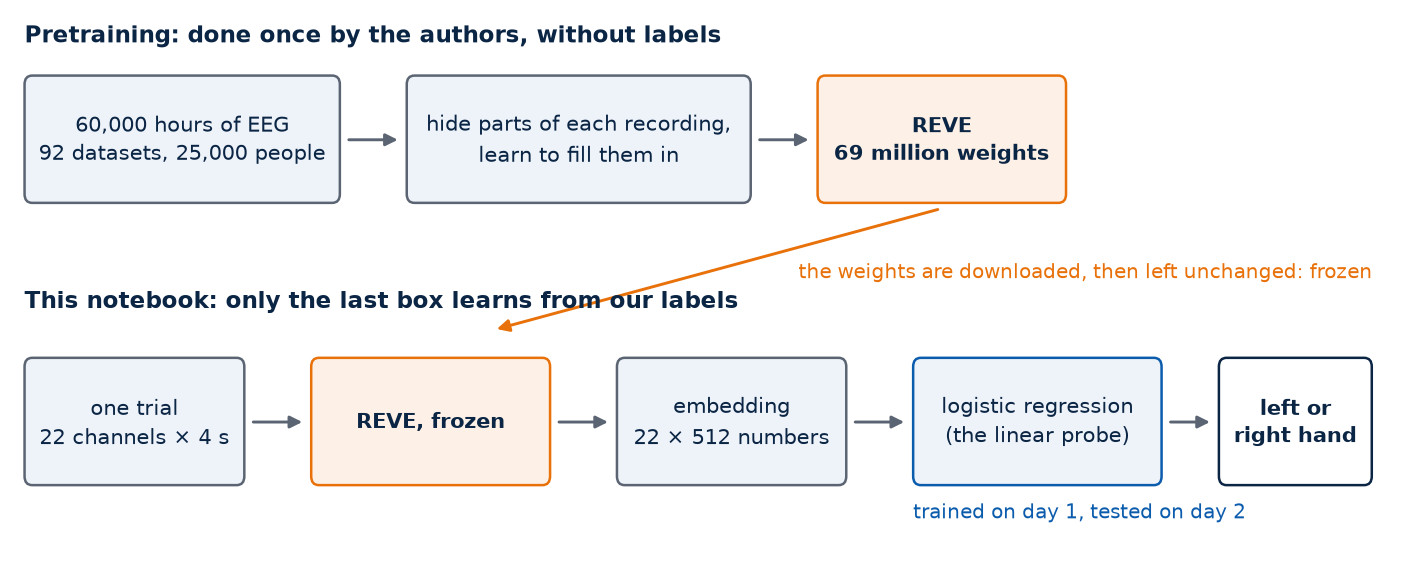

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: pretraining, self-supervised learning, frozen weights</b><br>A <b>foundation model</b> is a large neural network trained once on a very large and varied collection of data, then reused for many tasks. The first training is called <b>pretraining</b>. It needs no labels: the model is given recordings with pieces hidden and learns to fill them in. This is <b>self-supervised learning</b>, and to succeed the model has to pick up the regularities of EEG: rhythms, how neighbouring electrodes relate, what artefacts look like.<br>What the network has learned is stored in its <b>weights</b>, the millions of numbers that define its computations. We download them and choose how to use them. Here we keep them <b>frozen</b> (unchanged) and use the model as a fixed machine that turns a trial into numbers. Notebook 4 changes the weights instead, which is called <b>fine-tuning</b>.</div>

<div style="border-left:5px solid #5B6472; background:#F3F4F6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#5B6472;">The model</b><br><b>REVE</b> (El Ouahidi et al., 2025) was pretrained on about 60,000 hours of EEG from 92 datasets and 25,000 people. The version we use, <code>brain-bzh/reve-base</code>, has 69 million weights. According to the paper, BCI IV 2a was not part of the pretraining data: REVE has never seen our participants.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: embedding and linear probe</b><br>The numbers the model produces for a trial are its <b>embedding</b>, also called a <b>representation</b>. A <b>linear probe</b> is the simplest way to ask what an embedding contains: train a linear classifier on it, here a logistic regression, and look at its score. If a straight line is enough to separate left from right, the information was already laid out by the model. In the vocabulary of notebook 2, REVE replaces CSP and the tangent space: it is the step that makes the <b>features</b>.</div>

## 2. Load REVE and pass trials through it

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Four steps, all visible below: load the pretrained weights, prepare the trials the way the model was pretrained, pass them through, and keep one vector of 512 numbers per electrode.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Load the pretrained model

**Braindecode** gives access to pretrained EEG models with one call, `from_pretrained`. The weights come from the Hugging Face Hub the first time (280 MB; notebook 0 has already downloaded them). We tell the model which electrodes we have and how long a trial is.

In [3]:
# ---- Load REVE with its pretrained weights
from braindecode.models import REVE

model = REVE.from_pretrained(
    "brain-bzh/reve-base",                               # the pretrained weights, on the Hugging Face Hub
    n_chans=22,                                          # our 22 electrodes
    chs_info=[{"ch_name": name} for name in mf.CHANNELS],    # ... and their names: C3, Cz, C4, ...
    n_times=800, sfreq=200,                              # a trial is 4 s at 200 Hz, the rate REVE was pretrained at
    n_outputs=2,                                         # a small classification layer, not used in this notebook
).eval()                                                 # eval(): we use the model, we do not train it

print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.0f} million weights")

69 million weights


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Tell the model where the electrodes are

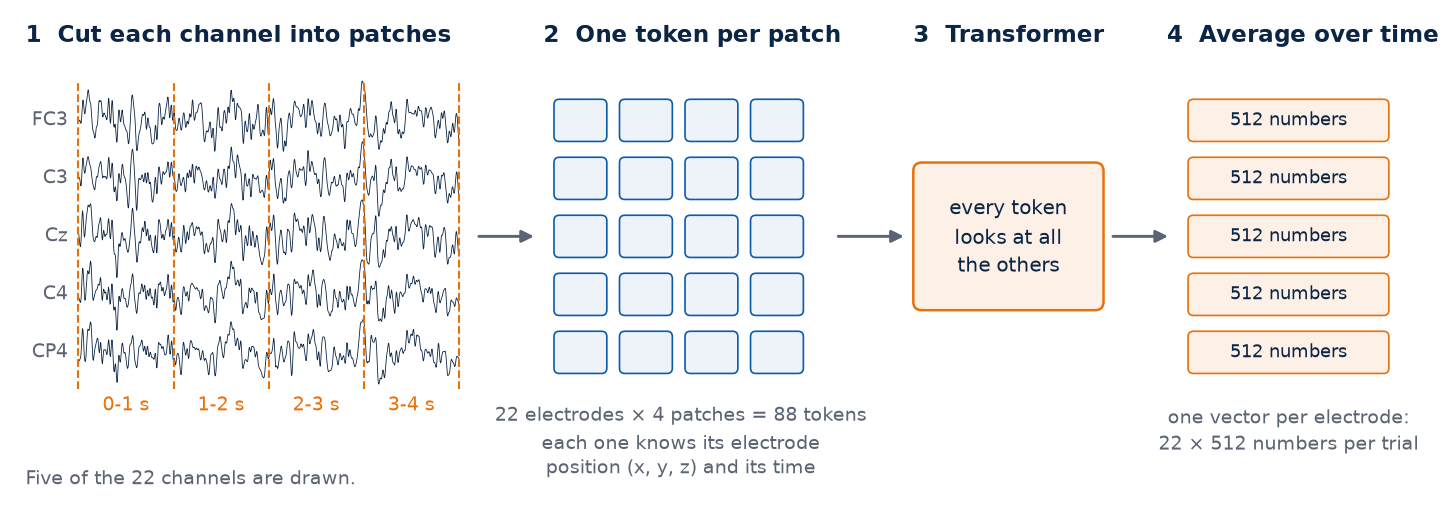

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: patches, tokens, positions</b><br>A transformer works on a sequence of pieces called <b>tokens</b>. In a language model a token is a piece of a word. REVE cuts each channel into <b>patches</b> of about one second, and each patch becomes one token: a 4 s trial with 22 channels gives 22 × 4 = 88 tokens. Each token is told <b>where and when</b> it was recorded: the position of its electrode in space (x, y, z) and its time. This is how one model can read caps with different electrodes, which is the main obstacle to pooling EEG datasets.<br>Inside the transformer, every token is updated many times using all the others (<b>attention</b>). At the output, each token is a list of 512 numbers.</div>

In [4]:
# ---- The position of each electrode, which REVE takes as a second input
positions = model.get_positions(mf.CHANNELS)             # looked up by electrode name
print("positions:", tuple(positions.shape), "(electrodes, xyz)")
print("C3:", positions[mf.CHANNELS.index("C3")].numpy().round(2), "| C4:", positions[mf.CHANNELS.index("C4")].numpy().round(2))

positions: (22, 3) (electrodes, xyz)
C3: [-0.07 -0.01  0.06] | C4: [ 0.07 -0.01  0.06]


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Prepare the trials the way REVE was pretrained

A pretrained model expects its input in the form it saw during pretraining. For REVE: EEG sampled at 200 Hz, and each channel of each trial **z-scored** (mean 0, standard deviation 1), with extreme values clipped. The decoders of notebook 2 saw 8 to 30 Hz; REVE gets 0.5 to 99.5 Hz and has to find the useful part itself.

In [5]:
# ---- The trials of one participant at 200 Hz, then z-scored
X200, y_p, meta_p = mf.load_epochs([SUBJECT], sfreq=200, fmin=0.5, fmax=99.5)       # trials x 22 channels x 800 samples
day1 = (meta_p["session"] == "0train").to_numpy()
day2 = (meta_p["session"] == "1test").to_numpy()


def prepare(X):
    """Z-score each channel of each trial, clip at 15 standard deviations, and make a PyTorch tensor."""
    X = (X - X.mean(axis=-1, keepdims=True)) / (X.std(axis=-1, keepdims=True) + 1e-8)
    return torch.from_numpy(np.clip(X, -15, 15).astype(np.float32))


x = prepare(X200)
print("x:", tuple(x.shape), "(trials, channels, samples)")

x: (288, 22, 800) (trials, channels, samples)


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Pass 8 trials through the model

`return_features=True` asks for the tokens instead of a class. `torch.no_grad()` says that we only compute the output: nothing will be learned.

In [6]:
# ---- From 8 trials to their tokens
with torch.no_grad():
    tokens = model(x[:8], pos=positions.expand(8, -1, -1), return_features=True)["features"]
print("tokens:", tuple(tokens.shape), "(trials, electrodes, patches, numbers per token)")

tokens: (8, 22, 4, 512) (trials, electrodes, patches, numbers per token)


Each of the 22 electrodes gives 4 tokens of 512 numbers, as in the figure.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> From tokens to one embedding per trial

Average the 4 tokens of each electrode, which leaves one vector of 512 numbers per electrode.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>tokens</code> has the axes (trials, electrodes, patches, numbers). <code>tokens.mean(dim=2)</code> averages over the patches. In PyTorch the axis is called <code>dim</code>.</div>

In [7]:
# ---- Exercise: average the tokens over the patches
embedding = ...                                      # <--- mean of `tokens` over its patch axis: (trials, electrodes, numbers)

In [8]:
#@title Solution (try first)
# ---- Average the tokens over the patches
embedding = tokens.mean(dim=2)
print("embedding:", tuple(embedding.shape), "(trials, electrodes, numbers)")

embedding: (8, 22, 512) (trials, electrodes, numbers)


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Embed every trial of your participant

The same two lines, in a loop over batches of 32 trials. About 15 seconds for the 288 trials of one participant on a laptop.

In [9]:
# ---- The embedding of every trial of one participant
def embed(model, x, positions, batch_size=32):
    """Frozen embeddings: trials x electrodes x 512, the tokens of each electrode averaged over time."""
    out = []
    with torch.no_grad():
        for i in range(0, len(x), batch_size):
            batch = x[i:i + batch_size]
            tokens = model(batch, pos=positions.expand(len(batch), -1, -1), return_features=True)["features"]
            out.append(tokens.mean(dim=2))
    return torch.cat(out).numpy()


start = time.time()
Z_p = embed(model, x, positions)
print("Z_p:", Z_p.shape, f"(trials, electrodes, numbers), computed in {time.time() - start:.0f} s")

Z_p: (288, 22, 512) (trials, electrodes, numbers), computed in 4 s


## 3. The embeddings of our trials

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>An embedding cannot be read by eye. Across all trials, embeddings differ more between people than between hands.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Embeddings of all participants

For the 2,592 trials of the nine participants the same loop takes a few minutes on a laptop, so its result ships with the tutorial package: the **cache**. We check that it matches what we just computed.

In [10]:
# ---- The cached embeddings of every trial, and a check against our own
cache = mf.load_embedding_cache(SUBJECTS)
Z, y, subject, session = cache["X"], cache["y"], cache["subject"], cache["session"]
train = session == "0train"                          # day 1
test = session == "1test"                            # day 2
flat = Z.reshape(len(Z), -1)                         # one row of 22 x 512 numbers per trial

print("Z:", Z.shape, "(trials, electrodes, numbers)")
r = np.corrcoef(Z_p.ravel(), Z[subject == SUBJECT].ravel())[0, 1]
print(f"Correlation between the embeddings we computed for participant {SUBJECT} and the cache: {r:.4f}")

Z: (2592, 22, 512) (trials, electrodes, numbers)
Correlation between the embeddings we computed for participant 1 and the cache: 1.0000


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> What an embedding looks like

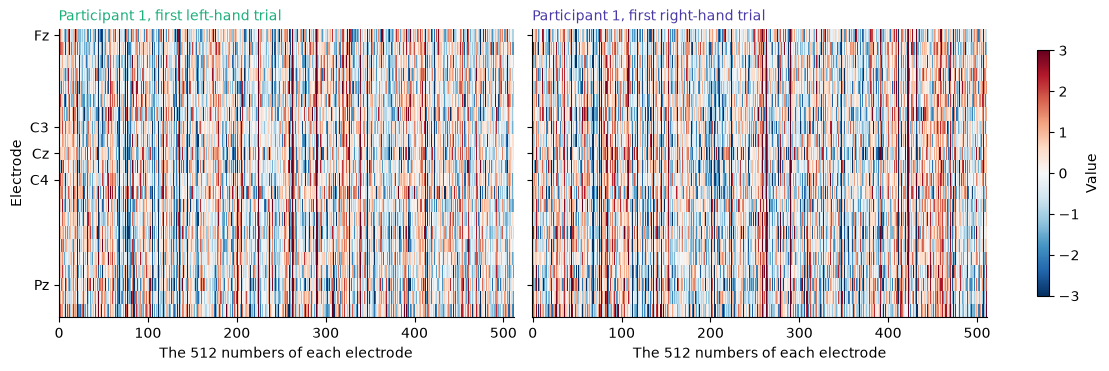

In [11]:
# ---- The embedding of one left-hand and one right-hand trial
mf.plot.embeddings(Z_p, y_p, title=f"Participant {SUBJECT}, ")

Nothing here can be read by eye, and the two trials look alike. An embedding is not a picture of the signal: each of its numbers is a mixture computed by the network, with no unit and no name. What it contains has to be measured, which is what a probe does.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> What do the embeddings organise first?

**PCA** (notebook 2) finds the two directions along which the trials vary most. We draw all the trials in that plane, coloured by participant and by imagined hand.

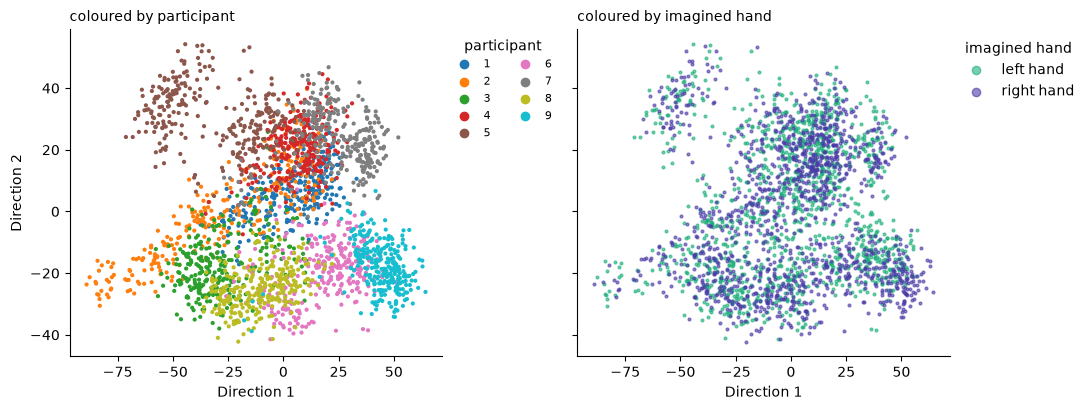

In [12]:
# ---- Every trial in the two main directions of the embeddings
points = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(flat))
mf.plot.plane(points, subject, y)

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>The trials form one cloud per participant, and within each cloud the two hands are mixed. The largest differences between embeddings are differences between people. EEG differs a lot from one person to another (head shape, cap position, the rhythms themselves), and the embeddings keep that. The information about the hand may still be there, along directions with less variance. A probe looks for it with the labels.</div>

## 4. A linear probe on one participant

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>A linear probe asks one question: is the information laid out simply enough in the embedding for a straight line to find it?</div>

<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Watch out: more features than trials</b><br>One trial is now 22 × 512 = 11,264 numbers, and we have 144 training trials. With far more features than trials, a classifier can always find a combination that separates the training trials perfectly, by using their noise: the <b>overfitting</b> of notebook 2, in its strongest form. Two steps keep it under control.<br><b>Standardising</b>: each feature is rescaled to mean 0 and standard deviation 1 on the training trials, so that no feature counts more because its numbers happen to be larger.<br><b>Regularisation</b>: the logistic regression pays a penalty for large weights, which pushes it towards simple rules that rely a little on many features. The parameter <code>C</code> sets the penalty: the smaller <code>C</code>, the stronger the penalty.</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Build the probe and train it

Flatten the embeddings into one row per trial, then fit a pipeline of two steps on day 1: a `StandardScaler` and a `LogisticRegression` with the penalty `C` of the parameters.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>Z_p.reshape(len(Z_p), -1)</code> keeps the trials and puts everything else on one row. <code>make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000))</code>, then <code>probe.fit(features[day1], y_p[day1])</code>.</div>

In [13]:
# ---- Exercise: the linear probe, fitted on day 1
features = ...                                       # <--- Z_p reshaped to (trials, 22 * 512)
probe = ...                                          # <--- make_pipeline(StandardScaler(), LogisticRegression(...))
fitted = ...                                         # <--- probe.fit(features of day 1, labels of day 1)

In [14]:
#@title Solution (try first)
# ---- The linear probe, fitted on day 1
features = Z_p.reshape(len(Z_p), -1)
probe = make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000))
probe.fit(features[day1], y_p[day1])

scores = {"Day 1 (training)": balanced_accuracy_score(y_p[day1], probe.predict(features[day1])),
          "Day 2 (test)": balanced_accuracy_score(y_p[day2], probe.predict(features[day2]))}
print(f"{features.shape[1]} features for {day1.sum()} training trials")
print(f"Participant {SUBJECT}, REVE frozen + LR:", ", ".join(f"{100 * value:.0f} % on {name.lower()}" for name, value in scores.items()))

11264 features for 144 training trials
Participant 1, REVE frozen + LR: 100 % on day 1 (training), 69 % on day 2 (test)


With participant 1 the probe is right for every training trial and for 69 % of the day-2 trials. A perfect training score with 11,264 features says nothing: the test score is the only one that counts. The same participant gave 83 % with CSP + LDA and 88 % with tangent space + LR in notebook 2.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> See the probe's answers

The logistic regression gives each trial one number, its **decision value**: positive means "right hand", negative "left hand", and the further from 0 the more confident.

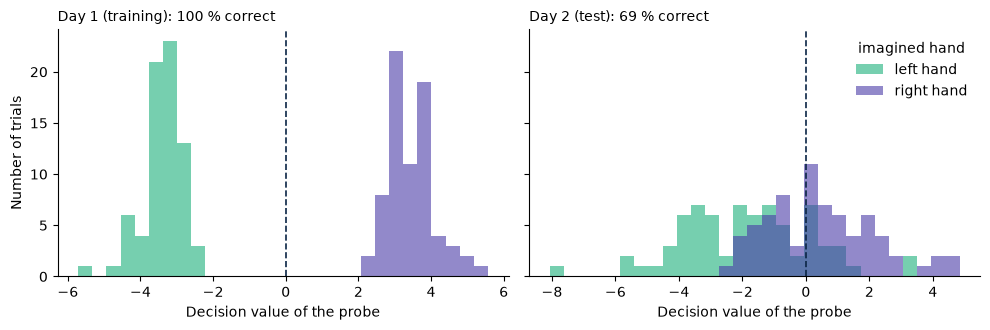

In [15]:
# ---- Decision values of the probe on each day
mf.plot.decision_values(probe.decision_function(features), y_p, {"Day 1 (training)": day1, "Day 2 (test)": day2}, scores)

On day 1 the two hands are far apart: the probe has learned its training trials by heart. On day 2 the two groups overlap, and both sit to the left of where they were: many right-hand trials fall on the "left" side of 0. This is the same shift between days as in the confusion matrix of notebook 2.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Where on the head is the information?

REVE gives one vector per electrode. We train one probe per electrode, each on the 512 numbers of that electrode alone, for every participant, and draw the mean score of each electrode.

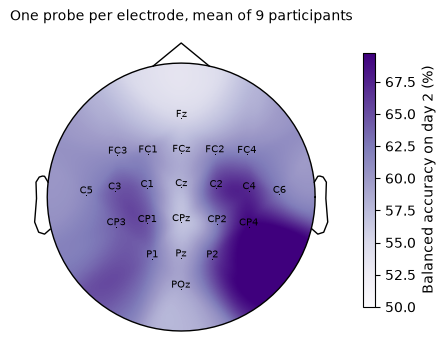

In [16]:
# ---- One probe per electrode: mean balanced accuracy on day 2 over the participants
def make_probe():
    return make_pipeline(StandardScaler(), LogisticRegression(C=C, max_iter=2000))


per_electrode = np.array([mf.evaluate.day2(make_probe, Z[:, k], y, subject, train, test, SUBJECTS)["balanced_accuracy"].mean()
                          for k in range(len(mf.CHANNELS))])
mf.plot.head_scores(100 * per_electrode, f"One probe per electrode, mean of {len(SUBJECTS)} participants")

With the 9 participants, the best probes are on the electrodes over and behind the motor cortex, on both sides (CP4 70 %, C4 67 %, C2 66 %), and the weakest are on the midline. REVE kept the information where notebook 1 found it: the vector of an electrode describes what happens near that electrode.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> One vector per trial instead of one per electrode

A common recipe averages the embedding over electrodes too, which leaves a single vector of 512 numbers per trial. Try it on your participant.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>Z_p</code> has the axes (trials, electrodes, numbers): <code>Z_p.mean(axis=1)</code>. Then fit a new probe with <code>make_probe()</code> on day 1 and score it on day 2, as above.</div>

In [17]:
# ---- Exercise: a probe on the embedding averaged over electrodes
averaged = ...                                       # <--- mean of Z_p over the electrode axis: (trials, 512)
score_averaged = ...                                 # <--- balanced accuracy on day 2 of make_probe() fitted on day 1

In [18]:
#@title Solution (try first)
# ---- A probe on the embedding averaged over electrodes
averaged = Z_p.mean(axis=1)
score_averaged = balanced_accuracy_score(y_p[day2], make_probe().fit(averaged[day1], y_p[day1]).predict(averaged[day2]))
print(f"Participant {SUBJECT}: {100 * score_averaged:.0f} % with one vector per trial, "
      f"{100 * scores['Day 2 (test)']:.0f} % with one vector per electrode")

Participant 1: 51 % with one vector per trial, 69 % with one vector per electrode


With participant 1 the score falls to chance. Averaging over electrodes erases where things happen on the head, and for left against right hand the side of the head is the whole signal. For a task where location matters less, such as sleep staging, the average may be enough.

## 5. All participants, against the classical decoders

<div style="border-left:5px solid #B45309; background:#FEF6E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#B45309;">Question</b><br>Make a prediction before running the next cell: will a model pretrained on 60,000 hours of EEG beat CSP, a method from the year 2000?</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The same evaluation as in notebook 2

One probe per participant, trained on day 1 and tested on day 2. `mf.evaluate.day2` repeats what we did above for each participant.

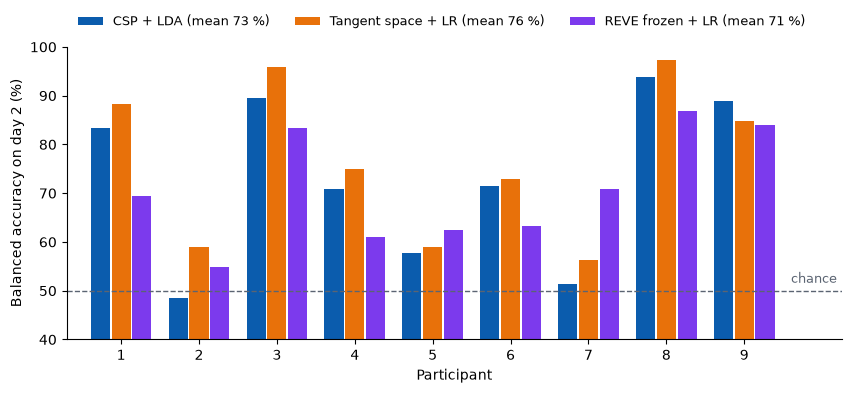

subject,1,2,3,4,5,6,7,8,9,mean
method,,,,,,,,,,
CSP + LDA,83.0,49.0,90.0,71.0,58.0,72.0,51.0,94.0,89.0,73.0
Tangent space + LR,88.0,59.0,96.0,75.0,59.0,73.0,56.0,97.0,85.0,76.0
REVE frozen + LR,69.0,55.0,83.0,61.0,62.0,63.0,71.0,87.0,84.0,71.0


In [19]:
# ---- REVE frozen + LR for every participant, next to the classical decoders of notebook 2
frozen = mf.evaluate.day2(make_probe, flat, y, subject, train, test, SUBJECTS).assign(method="REVE frozen + LR")

classical_file = RESULTS_DIR / "classical.csv"
if not classical_file.exists():
    raise FileNotFoundError("Run 02_classical.ipynb first: it saves the scores of the classical decoders.")
everything = pd.concat([pd.read_csv(classical_file), frozen])
table = everything.pivot(index="method", columns="subject", values="balanced_accuracy")
table = table.loc[["CSP + LDA", "Tangent space + LR", "REVE frozen + LR"], SUBJECTS]
mf.plot.bars(table)
(100 * table.assign(mean=table.mean(axis=1))).round(0)

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>With the 9 participants, the frozen REVE with a linear probe reaches 71 % on average, below CSP + LDA (73 %) and tangent space + LR (76 %). It is lower than tangent space + LR in 7 of 9 participants. The exception is participant 7, at chance with both classical decoders and at 71 % here: the embeddings hold something about this person's imagery that power in the 8 to 30 Hz band does not. A model pretrained on 60,000 hours of EEG does not, used this way, beat methods from 2000 and 2012 on this dataset.</div>

In [20]:
# ---- Save the scores for notebooks 4 and 5
frozen.assign(training_data="own day 1", training_labels="100 %", adapted_parameters="head only",
              hardware="CPU").to_csv(RESULTS_DIR / "fm_frozen.csv", index=False)
print("Saved", len(frozen), "rows to", RESULTS_DIR / "fm_frozen.csv")

Saved 9 rows to results/fm_frozen.csv


## 6. With fewer labels, and with several participants

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Two claims are often made for foundation models: they need fewer labels, and they can learn from many people. On this dataset the first does not hold for the frozen model, and the second does.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: label efficiency</b><br>Labels are the expensive part of an experiment: each labelled trial is several seconds of a person's time. A <b>label-efficiency curve</b> tests whether a decoder needs fewer of them: train on fewer and fewer labelled trials and watch the score.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The three decoders with 10 to 144 training trials

For each size the training trials are drawn at random from day 1, five times; the test set is always the whole of day 2. The classical decoders need the trials themselves, loaded as in notebook 2. About one minute.

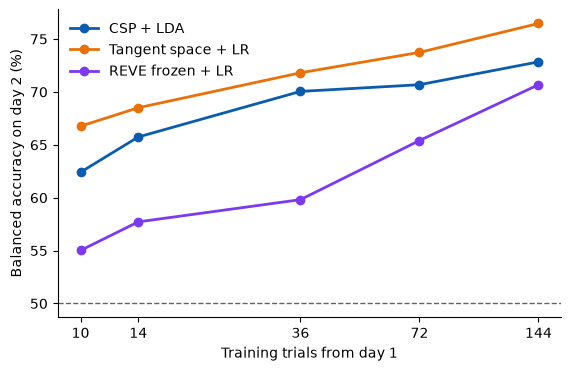

,10,14,36,72,144
CSP + LDA,62.0,66.0,70.0,71.0,73.0
Tangent space + LR,67.0,69.0,72.0,74.0,76.0
REVE frozen + LR,55.0,58.0,60.0,65.0,71.0


In [21]:
# ---- The three decoders: what each takes as input, and how it is built
from mne.decoding import CSP
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

X_band = mf.load_epochs(SUBJECTS, fmin=8, fmax=30)[0].astype(np.float64)       # the input of the classical decoders
DECODERS = {                                                                   # name -> (input, function that builds it)
    "CSP + LDA": (X_band, lambda: make_pipeline(CSP(n_components=4, log=True), LinearDiscriminantAnalysis())),
    "Tangent space + LR": (X_band, lambda: make_pipeline(Covariances(estimator="oas"), TangentSpace(),
                                                         LogisticRegression(max_iter=1000))),
    "REVE frozen + LR": (flat, make_probe),
}
SIZES = [10, 14, 36, 72, 144]                                                  # 5 per class, then 10, 25, 50 and 100 % of day 1

curve = pd.DataFrame({name: mf.evaluate.with_fewer_labels(make, inputs, y, subject, train, test, SUBJECTS, SIZES)
                      for name, (inputs, make) in DECODERS.items()})
curve.rename_axis("training_trials").to_csv(RESULTS_DIR / "label_curve.csv")       # for notebooks 4 and 5
mf.plot.label_curve(curve)
(100 * curve).round(0).T

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>With the 9 participants, the expected advantage does not appear. The classical decoders lose 6 to 10 points between 144 and 10 training trials; the frozen REVE loses 16 and is close to chance with 10 trials (55 %). The reason is the number of features: 4 for CSP, 253 for the tangent space, 11,264 for the embedding. With 10 trials and 11,264 features a linear probe has very little to go on.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> One decoder for everyone

Until now every decoder was trained on one person. The embeddings of REVE are in the same space for everyone, so we can train **one** probe on the day 1 of all participants together. The classical pipelines can be trained that way too.

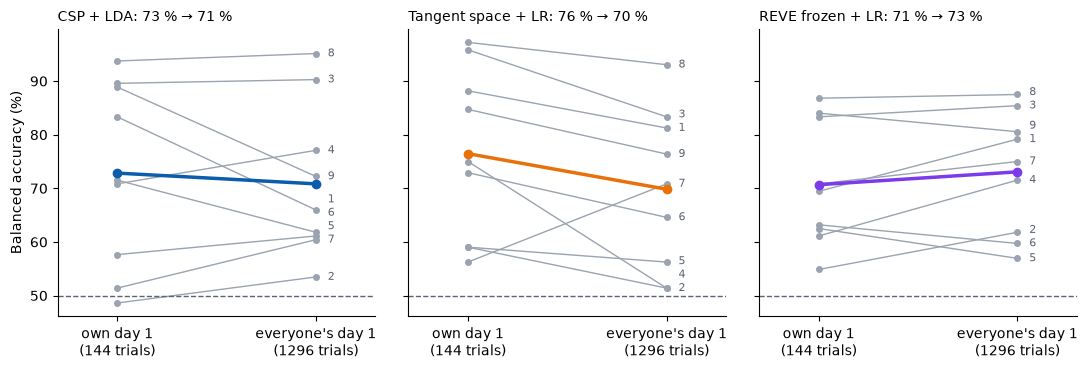

In [22]:
# ---- One decoder trained on everyone's day 1, tested on each participant's day 2
pooled = pd.DataFrame({name: mf.evaluate.pooled(make, inputs, y, subject, train, test, SUBJECTS)
                       for name, (inputs, make) in DECODERS.items()}).T
pooled.T.rename_axis("subject").reset_index().melt("subject", var_name="method", value_name="balanced_accuracy").assign(
    training_data="everyone's day 1").to_csv(RESULTS_DIR / "pooled.csv", index=False)       # for notebooks 4 and 5
mf.plot.before_after(table, pooled, ["own day 1\n(144 trials)", f"everyone's day 1\n({train.sum()} trials)"])

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>With the 9 participants, the three decoders react differently. The classical decoders get worse when the other participants are added: 73 % to 71 % for CSP + LDA, 76 % to 70 % for tangent space + LR. Spatial filters and covariance matrices are specific to a head and a cap position, so other people's trials mostly add confusion. The probe on REVE gets better, from 71 % to 73 %: its embeddings are comparable enough across people for nine times more trials to help. Notebook 4 builds on this.</div>

<div style="border-left:5px solid #B45309; background:#FEF6E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#B45309;">Question</b><br>Why would decoders built on covariance matrices suffer when several people are pooled, while a probe on the embeddings does not?</div>

## 7. Other foundation models

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>REVE is one pretrained EEG model among several. Swapping models changes only the step that makes the embeddings; what each model needs as input is where the work is.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The same steps with CBraMod

**CBraMod** (Wang et al., 2025) is a smaller pretrained model, about 5 million weights. The steps are those of part 2: load, prepare, pass the trials through, average the tokens over time.

In [23]:
# ---- CBraMod in place of REVE, on the same trials
from braindecode.models import CBraMod

cbramod = CBraMod.from_pretrained(
    "braindecode/cbramod-pretrained",
    return_encoder_output=True,                          # give the tokens, not a class
    n_chans=22, chs_info=[{"ch_name": name} for name in mf.CHANNELS], n_times=800, sfreq=200,
).eval()

with torch.no_grad():
    tokens = cbramod(x[:8])                              # no electrode positions: CBraMod does not take them
print(f"CBraMod: {sum(p.numel() for p in cbramod.parameters()) / 1e6:.0f} million weights")
print("tokens:", tuple(tokens.shape), "(trials, electrodes, patches, numbers per token)")

CBraMod: 5 million weights
tokens: (8, 22, 4, 200) (trials, electrodes, patches, numbers per token)


Same layout of tokens as REVE, with 200 numbers per token instead of 512.

<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Watch out: one cap, many models</b><br>Other models are less accommodating. Each was pretrained with its own electrodes, trial length and sampling rate, and many refuse an input that differs. On our 22 channels and 4 s trials: <b>LaBraM</b> was saved for 15 s windows and has to be rebuilt for ours; <b>LUNA</b> wants 250 Hz; <b>EEGPT</b>, <b>BIOT</b> and <b>BENDR</b> expect their own fixed sets of channels and do not load at all without more work. This is the fragmentation of EEG data, seen from the side of the models. REVE takes electrode positions as input to avoid it.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Four models, the same probe

The package holds the preparation each model needs (`mf.models.RECIPES`, in `meeg_fm/models.py`), so that `mf.models.embed(name, X)` returns the embeddings of any of them. We embed every trial with each model and train the same probe. About one minute.

In [24]:
# ---- Embeddings of every trial from three other models, and the probe on each
X200_all = mf.load_epochs(SUBJECTS, sfreq=200, fmin=0.5, fmax=99.5)[0]             # the input prepared as for REVE

embeddings = {"REVE": Z}
for name, label in [("cbramod", "CBraMod"), ("labram", "LaBraM"), ("luna", "LUNA")]:
    embeddings[label] = mf.models.embed(name, X200_all)                            # trials x tokens x numbers

rows = {}
for label, E in embeddings.items():
    by_subject = mf.evaluate.day2(make_probe, E.reshape(len(E), -1), y, subject, train, test, SUBJECTS)
    rows[label] = {"tokens × numbers": f"{E.shape[1]} × {E.shape[2]}", **(100 * by_subject.set_index("subject")["balanced_accuracy"]).round(0),
                   "mean": round(100 * by_subject["balanced_accuracy"].mean(), 1)}
models_table = pd.DataFrame(rows).T
models_table["mean"].rename("balanced_accuracy").rename_axis("model").to_csv(RESULTS_DIR / "frozen_models.csv")   # for notebook 4
models_table

,tokens × numbers,1,2,3,4,5,6,7,8,9,mean
REVE,22 × 512,69.0,55.0,83.0,61.0,62.0,63.0,71.0,87.0,84.0,70.7
CBraMod,22 × 200,56.0,53.0,68.0,55.0,60.0,58.0,61.0,62.0,56.0,59.0
LaBraM,88 × 200,39.0,47.0,54.0,51.0,53.0,52.0,53.0,59.0,62.0,52.3
LUNA,25 × 256,49.0,51.0,52.0,49.0,51.0,55.0,51.0,56.0,57.0,52.3


<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>With the 9 participants and the same frozen probe: REVE 71 %, CBraMod 59 %, LaBraM and LUNA 52 %, which is chance. Read this table with care. It does not rank the models. Each one was fed our trials with one generic preparation, and a frozen linear probe is the weakest way to use any of them. LUNA merges the electrodes into a few tokens of its own, so the side of the head, which is our whole signal, is no longer laid out for a linear probe. What the table does show: frozen embeddings are not interchangeable, and a model that works out of the box on one dataset can give nothing on another without adaptation. Notebook 4 looks at that adaptation for REVE.</div>

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Look inside another model's embeddings

Pick one of the other models and draw its embeddings in their two main directions, as we did for REVE in part 3. Do they also form one cloud per participant?

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>embeddings</code> is a dictionary: <code>embeddings[&quot;CBraMod&quot;]</code>, <code>embeddings[&quot;LaBraM&quot;]</code> or <code>embeddings[&quot;LUNA&quot;]</code>. The rest of the cell flattens it, runs the PCA and draws the figure.</div>

In [25]:
# ---- Exercise: the embeddings of another model in their two main directions
E = ...                                              # <--- the embeddings of one model, from the `embeddings` dictionary

if E is not ...:                                     # runs once the line above is completed
    points_other = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(E.reshape(len(E), -1)))
    mf.plot.plane(points_other, subject, y)

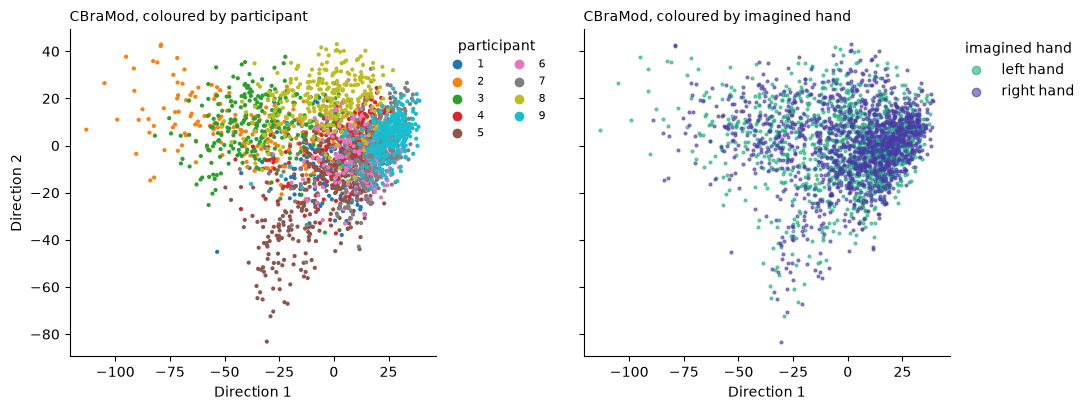

In [26]:
#@title Solution (try first)
# ---- The embeddings of CBraMod in their two main directions
E = embeddings["CBraMod"]
points_other = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(E.reshape(len(E), -1)))
mf.plot.plane(points_other, subject, y, name="CBraMod, ")

CBraMod's embeddings also group the trials by participant, with the two hands mixed inside each group, as REVE's did.

### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> Try to load a model that does not fit

Load **EEGPT** for our 22 channels and read the error. What does the model expect, and what would you have to change in the data to satisfy it?

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>from braindecode.models import EEGPT</code>, then <code>EEGPT.from_pretrained(&quot;braindecode/eegpt-pretrained&quot;, n_chans=22, chs_info=[...], n_times=1000, sfreq=250)</code> (<a href='https://braindecode.org/stable/generated/braindecode.models.EEGPT.html'>documentation</a>). Wrap the call in <code>try: ... except Exception as error: print(error)</code> so that the notebook keeps running. The weights are a 96 MB download.</div>

In [27]:
# ---- Type 3: load EEGPT on our 22 channels and read the error (optional)

In [28]:
#@title Solution (try first)
# ---- EEGPT on our 22 channels: the error says what the model expects
from braindecode.models import EEGPT

try:
    EEGPT.from_pretrained("braindecode/eegpt-pretrained", n_chans=22, n_times=1000, sfreq=250,
                          chs_info=[{"ch_name": name} for name in mf.CHANNELS])
except Exception as error:
    print(type(error).__name__ + ":", str(error)[:400])
# The saved EEGPT weights contain a table for its own 62 electrodes, and a model built for our 22 has a different
# one, so the loader refuses. Using EEGPT here means first mapping our electrodes onto its list, at its sampling rate.

RuntimeError: Error(s) in loading state_dict for EEGPT:
	size mismatch for chans_id: copying a param with shape torch.Size([1, 62]) from checkpoint, the shape in current model is torch.Size([1, 19]).


## 8. Go further (optional)

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> A participant the decoder has never seen

In part 6 the decoder had seen day 1 of the person it was tested on. Now leave one participant out completely: train on the other 8 (both days) and test on day 2 of the one left out. This is a decoder that needs no calibration for a new person.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>subject</code> holds the participant of each trial. <code>subject != LEFT_OUT</code> is True for the trials of everyone else.</div>

In [29]:
# ---- Exercise: train on 8 participants, test on the one left out
LEFT_OUT = 7                                         # the participant the decoders will never see
others = ...                                         # <--- True for the trials of every participant except LEFT_OUT

if others is not ...:                                # runs once the line above is completed
    held_out = (subject == LEFT_OUT) & test
    for name in ["Tangent space + LR", "REVE frozen + LR"]:
        inputs, make = DECODERS[name]
        score = balanced_accuracy_score(y[held_out], make().fit(inputs[others], y[others]).predict(inputs[held_out]))
        print(f"{name}, never saw participant {LEFT_OUT}: {100 * score:.0f} % "
              f"(trained on their own day 1: {100 * table.loc[name, LEFT_OUT]:.0f} %)")

In [30]:
#@title Solution (try first)
# ---- Train on 8 participants, test on day 2 of the one left out, for every participant
left_out = pd.DataFrame({name: mf.evaluate.left_out(DECODERS[name][1], DECODERS[name][0], y, subject, test, SUBJECTS)
                         for name in ["Tangent space + LR", "REVE frozen + LR"]}).T
(100 * left_out.assign(mean=left_out.mean(axis=1))).round(0)
# With the 9 participants both reach 68 to 69 % on a person they have never seen, with no calibration trial.
# For the tangent space that is 8 points below its own-participant score (76 %); for REVE only 2 points below (71 %).

,1,2,3,4,5,6,7,8,9,mean
Tangent space + LR,87.0,48.0,92.0,55.0,52.0,66.0,67.0,82.0,64.0,68.0
REVE frozen + LR,75.0,57.0,83.0,65.0,58.0,62.0,73.0,81.0,64.0,69.0


### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> How strong should the penalty be?

We set `C = 0.01` without looking. Compute the mean day-2 score of the probe on REVE for `C` from 0.0001 to 10. How much does the choice matter? And why would it be wrong to pick the best `C` from this curve?

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br>Loop over <code>np.logspace(-4, 1, 6)</code>. For each value, <code>mf.evaluate.day2(lambda: make_pipeline(StandardScaler(), LogisticRegression(C=value, max_iter=2000)), flat, y, subject, train, test, SUBJECTS)</code> gives the scores of every participant. For the second question, think of the leakage of notebook 2.</div>

In [31]:
# ---- Type 3: mean day-2 score of the probe for several values of C (optional)

In [32]:
#@title Solution (try first)
# ---- Mean day-2 score of the probe for several values of C
by_c = pd.Series({value: mf.evaluate.day2(lambda: make_pipeline(StandardScaler(), LogisticRegression(C=value, max_iter=2000)),
                                          flat, y, subject, train, test, SUBJECTS)["balanced_accuracy"].mean()
                  for value in np.logspace(-4, 1, 6)})
(100 * by_c).round(1)
# With the 9 participants the score stays between 70 % and 71 % for C from 0.001 to 1, and drops to 68 % at both ends.
# Picking the best C from this curve would use day 2 to choose a setting: leakage. C must be chosen on day 1 only,
# for example by cross-validation inside the training trials.

0.0001     67.8
0.0010     70.0
0.0100     70.7
0.1000     70.8
1.0000     70.2
10.0000    67.7
dtype: float64

## 9. Summary

| Step | Function | Package |
|---|---|---|
| Load a pretrained model | `REVE.from_pretrained`, `CBraMod.from_pretrained` | Braindecode |
| Electrode positions | `model.get_positions` | Braindecode |
| Prepare the input | resample to 200 Hz (`mf.load_epochs`), z-score | MNE, NumPy |
| Tokens | `model(x, pos=..., return_features=True)` under `torch.no_grad()` | PyTorch |
| Embedding | mean of the tokens over time | PyTorch |
| Linear probe | `StandardScaler`, `LogisticRegression(C=...)` | scikit-learn |
| Other models | `mf.models.embed` | tutorial package |

<div style="border-left:5px solid #15803D; background:#ECF8EF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#15803D;">Take-aways</b><br><ul style='margin:0;'><li>Using a pretrained model takes four steps: load the weights, prepare the input as in pretraining, pass the trials through, pool the tokens into an embedding.</li><li>With the 9 participants, the frozen REVE with a linear probe reaches 71 % on day 2, below CSP + LDA (73 %) and tangent space + LR (76 %).</li><li>It does not need fewer labels here, but it improves when trained on several participants, where the classical decoders get worse, and it decodes participant 7.</li><li>Other pretrained models give 59 % (CBraMod) or chance (LaBraM, LUNA) with the same probe, and several do not load on our electrodes at all.</li><li>A frozen model with a linear probe is the simplest way to use a foundation model. Notebook 4 changes the weights.</li></ul></div>

**Next**: `04_fm_finetune.ipynb`.

<details><summary>References</summary>

- Alain, G., & Bengio, Y. (2017). Understanding intermediate layers using linear classifier probes. *International Conference on Learning Representations (workshop track)*. https://arxiv.org/abs/1610.01644
- Bommasani, R., Hudson, D. A., Adeli, E., Altman, R., Arora, S., von Arx, S., ... Liang, P. (2021). On the opportunities and risks of foundation models. *arXiv*. https://arxiv.org/abs/2108.07258
- Döner, B., Ingolfsson, T. M., Benini, L., & Li, Y. (2025). LUNA: Efficient and topology-agnostic foundation model for EEG signal analysis. *Advances in Neural Information Processing Systems 38*. https://arxiv.org/abs/2510.22257
- El Ouahidi, Y., Lys, J., Thölke, P., Farrugia, N., Pasdeloup, B., Gripon, V., Jerbi, K., & Lioi, G. (2025). REVE: A foundation model for EEG, adapting to any setup with large-scale pretraining on 25,000 subjects. *Advances in Neural Information Processing Systems 38*. https://arxiv.org/abs/2510.21585
- Jiang, W.-B., Zhao, L.-M., & Lu, B.-L. (2024). Large brain model for learning generic representations with tremendous EEG data in BCI. *International Conference on Learning Representations*. https://arxiv.org/abs/2405.18765
- Schirrmeister, R. T., Springenberg, J. T., Fiederer, L. D. J., Glasstetter, M., Eggensperger, K., Tangermann, M., ... Ball, T. (2017). Deep learning with convolutional neural networks for EEG decoding and visualization. *Human Brain Mapping, 38*(11), 5391-5420. https://doi.org/10.1002/hbm.23730
- Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., Kaiser, Ł., & Polosukhin, I. (2017). Attention is all you need. *Advances in Neural Information Processing Systems 30*. https://arxiv.org/abs/1706.03762
- Wang, J., Zhao, S., Luo, Z., Zhou, Y., Jiang, H., Li, S., Li, T., & Pan, G. (2025). CBraMod: A criss-cross brain foundation model for EEG decoding. *International Conference on Learning Representations*. https://arxiv.org/abs/2412.07236
</details>